# Importing Libraries

In [ ]:
##from google.colab import drive
##drive.mount('/content/drive')


In [1]:
import talos
import astetik
import chances
import kerasplotlib
import numpy as np
import pandas as pd
import requests
import sklearn
import statsmodels.api as sm
import tensorflow as tf
import tqdm
import wrangle

print("All imports successful!")

All imports successful!


In [3]:
# Core data libraries
import numpy as np
import pandas as pd
import talos
# Text processing libraries
import re
import spacy
nlp = spacy.load('en_core_web_sm')
from spacy.lang.en import English
from spacy.lang.en.stop_words import STOP_WORDS
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('stopwords')
import string
from string import ascii_lowercase
# Progress bars
from tqdm import tqdm  # tqdm_notebook is deprecated
# Other utilities
import itertools
import io
from functools import reduce
# Plotting
import matplotlib.pyplot as plt
%matplotlib inline
# TensorFlow / Keras imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Dense, Input, LSTM, Embedding, Dropout, Activation
from tensorflow.keras.layers import Bidirectional, GlobalMaxPool1D, Conv1D, MaxPooling1D, BatchNormalization
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras import initializers, regularizers, constraints, optimizers, layers


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Importing Data

In [ ]:
train = pd.read_csv('../DataSet/train.csv')


In [6]:
train.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [ ]:
test=pd.read_csv('../DataSet/test.csv')


In [8]:
test.head()

,id,comment_text
0,00001cee341fdb12,Yo bitch Ja Rule is more succesful then you'll...
1,0000247867823ef7,== From RfC == \n\n The title is fine as it is...
2,00013b17ad220c46,""" \n\n == Sources == \n\n * Zawe Ashton on Lap..."
3,00017563c3f7919a,":If you have a look back at the source, the in..."
4,00017695ad8997eb,I don't anonymously edit articles at all.


# Data Exploration

Checking for missing values

In [13]:
train.isnull().any()

id               False
comment_text     False
toxic            False
severe_toxic     False
obscene          False
threat           False
insult           False
identity_hate    False
dtype: bool

In [15]:
test.isnull().any()


id              False
comment_text    False
dtype: bool

In [17]:
labels = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
y = train[labels].values

# Data Pre-processing

## Text Normalization

* Removing Characters in between Text
* Removing Repeated Characters
* Converting data to lower-case
* Removing Numbers from the data
* Remove Punctuation
* Remove Whitespaces
* Removing spaces in between words
* Removing "\n"
* Remove Non-english characters

In [22]:
RE_PATTERNS = {
    ' american ':
        [
            'amerikan'
        ],

    ' adolf ':
        [
            'adolf'
        ],


    ' hitler ':
        [
            'hitler'
        ],

    ' fuck':
        [
            '(f)(u|[^a-z0-9 ])(c|[^a-z0-9 ])(k|[^a-z0-9 ])([^ ])*',
            '(f)([^a-z]*)(u)([^a-z]*)(c)([^a-z]*)(k)',
            ' f[!@#\$%\^\&\*]*u[!@#\$%\^&\*]*k', 'f u u c',
            '(f)(c|[^a-z ])(u|[^a-z ])(k)', r'f\*',
            'feck ', ' fux ', 'f\*\*', 'f**k','fu*k',
            'f\-ing', 'f\.u\.', 'f###', ' fu ', 'f@ck', 'f u c k', 'f uck', 'f ck'
        ],

    ' ass ':
        [
            '[^a-z]ass ', '[^a-z]azz ', 'arrse', ' arse ', '@\$\$',
            '[^a-z]anus', ' a\*s\*s', '[^a-z]ass[^a-z ]',
            'a[@#\$%\^&\*][@#\$%\^&\*]', '[^a-z]anal ', 'a s s','a55', '@$$'
        ],

    ' ass hole ':
        [
            ' a[s|z]*wipe', 'a[s|z]*[w]*h[o|0]+[l]*e', '@\$\$hole', 'a**hole'
        ],

    ' bitch ':
        [
            'b[w]*i[t]*ch', 'b!tch',
            'bi\+ch', 'b!\+ch', '(b)([^a-z]*)(i)([^a-z]*)(t)([^a-z]*)(c)([^a-z]*)(h)',
            'biatch', 'bi\*\*h', 'bytch', 'b i t c h', 'b!tch', 'bi+ch', 'l3itch'
        ],

    ' bastard ':
        [
            'ba[s|z]+t[e|a]+rd'
        ],

    ' trans gender':
        [
            'transgender'
        ],

    ' gay ':
        [
            'gay'
        ],

    ' cock ':
        [
            '[^a-z]cock', 'c0ck', '[^a-z]cok ', 'c0k', '[^a-z]cok[^aeiou]', ' cawk',
            '(c)([^a-z ])(o)([^a-z ]*)(c)([^a-z ]*)(k)', 'c o c k'
        ],

    ' dick ':
        [
            ' dick[^aeiou]', 'deek', 'd i c k', 'dik'
        ],

    ' suck ':
        [
            'sucker', '(s)([^a-z ]*)(u)([^a-z ]*)(c)([^a-z ]*)(k)', 'sucks', '5uck', 's u c k'
        ],

    ' cunt ':
        [
            'cunt', 'c u n t'
        ],

    ' bull shit ':
        [
            'bullsh\*t', 'bull\$hit'
        ],

    ' homo sex ual':
        [
            'homosexual'
        ],

    ' jerk ':
        [
            'jerk'
        ],

    ' idiot ':
        [
            'i[d]+io[t]+', '(i)([^a-z ]*)(d)([^a-z ]*)(i)([^a-z ]*)(o)([^a-z ]*)(t)', 'idiots'
                                                                                      'i d i o t'
        ],

    ' dumb ':
        [
            '(d)([^a-z ]*)(u)([^a-z ]*)(m)([^a-z ]*)(b)'
        ],

    ' shit ':
        [
            'shitty', '(s)([^a-z ]*)(h)([^a-z ]*)(i)([^a-z ]*)(t)', 'shite', '\$hit', 's h i t', '$h1t'
        ],

    ' shit hole ':
        [
            'shythole'
        ],

    ' retard ':
        [
            'returd', 'retad', 'retard', 'wiktard', 'wikitud'
        ],

    ' rape ':
        [
            ' raped'
        ],

    ' dumb ass':
        [
            'dumbass', 'dubass'
        ],

    ' ass head':
        [
            'butthead'
        ],

    ' sex ':
        [
            'sexy', 's3x', 'sexuality'
        ],


    ' nigger ':
        [
            'nigger', 'ni[g]+a', ' nigr ', 'negrito', 'niguh', 'n3gr', 'n i g g e r'
        ],

    ' shut the fuck up':
        [
            'stfu', 'st*u'
        ],

    ' pussy ':
        [
            'pussy[^c]', 'pusy', 'pussi[^l]', 'pusses', 'p*ssy'
        ],

    ' faggot ':
        [
            'faggot', ' fa[g]+[s]*[^a-z ]', 'fagot', 'f a g g o t', 'faggit',
            '(f)([^a-z ]*)(a)([^a-z ]*)([g]+)([^a-z ]*)(o)([^a-z ]*)(t)', 'fau[g]+ot', 'fae[g]+ot',
        ],

    ' mother fucker':
        [
            ' motha ', ' motha f', ' mother f', 'motherucker',
        ],

    ' whore ':
        [
            'wh\*\*\*', 'w h o r e'
        ],
    ' fucking ':
        [
            'f*$%-ing'
        ],
}


In [24]:
def clean_text(text,remove_repeat_text=True, remove_patterns_text=True, is_lower=True):

  if is_lower:
    text=text.lower()

  if remove_patterns_text:
    for target, patterns in RE_PATTERNS.items():
      for pat in patterns:
        text=str(text).replace(pat, target)

  if remove_repeat_text:
    text = re.sub(r'(.)\1{2,}', r'\1', text)

  text = str(text).replace("\n", " ")
  text = re.sub(r'[^\w\s]',' ',text)
  text = re.sub('[0-9]',"",text)
  text = re.sub(" +", " ", text)
  text = re.sub("([^\x00-\x7F])+"," ",text)
  return text

Cleaning Training Data

In [27]:
train['comment_text']=train['comment_text'].apply(lambda x: clean_text(x))
train['comment_text'][1]

'd aww he matches this background colour i m seemingly stuck with thanks talk january utc '

Cleaning Test Data

In [29]:
test['comment_text']=test['comment_text'].apply(lambda x: clean_text(x))
test['comment_text'][1048]

'this is a university ip address just fyi '

## Lemmatization

In [31]:
comments_train=train['comment_text']
comments_test=test['comment_text']

In [32]:
comments_train=list(comments_train)
comments_test=list(comments_test)

In [33]:
wordnet_lemmatizer = WordNetLemmatizer()

In [34]:
def lemma(text, lemmatization=True):
  output=""
  if lemmatization:
    text=text.split(" ")
    for word in text:
       word1 = wordnet_lemmatizer.lemmatize(word, pos = "n")
       word2 = wordnet_lemmatizer.lemmatize(word1, pos = "v")
       word3 = wordnet_lemmatizer.lemmatize(word2, pos = "a")
       word4 = wordnet_lemmatizer.lemmatize(word3, pos = "r")
       output=output + " " + word4
  else:
    output=text

  return str(output.strip())

Lemmatizing Training Data

In [36]:
lemmatized_train_data = []

for line in tqdm(comments_train, total=159571):
    lemmatized_train_data.append(lemma(line))

100%|█████████████████████████████████████████████████████████████████████████| 159571/159571 [08:23<00:00, 317.11it/s]


In [37]:
lemmatized_train_data[152458]

'i agree with you about graemel s intention he be a revert nazi and wikipedia ha a way of protect against this report him to the wp rr three revert rule notice board post by report the revert nazi graemel ha show himself herself to be a revert nazi this be unacceptable on a site that be make by it s user and not it s admins if you feel you have be unjustly revert more than time over a hour period please report him her to the three revert noticeboard wp rr it be time to take back what be ours'

Lemmatizing Test Data

In [39]:
lemmatized_test_data = []

for line in tqdm(comments_test, total=len(comments_test)):
    lemmatized_test_data.append(lemma(line))

100%|█████████████████████████████████████████████████████████████████████████| 153164/153164 [06:52<00:00, 371.59it/s]


## Stopwords Removal

In [41]:
stopword_list=STOP_WORDS

Adding Single and Dual to STOP_WORDS

In [43]:
def iter_all_strings():
    for size in itertools.count(1):
        for s in itertools.product(ascii_lowercase, repeat=size):
            yield "".join(s)

dual_alpha_list=[]
for s in iter_all_strings():
    dual_alpha_list.append(s)
    if s == 'zz':
        break

In [44]:
dual_alpha_list.remove('i')
dual_alpha_list.remove('a')
dual_alpha_list.remove('am')
dual_alpha_list.remove('an')
dual_alpha_list.remove('as')
dual_alpha_list.remove('at')
dual_alpha_list.remove('be')
dual_alpha_list.remove('by')
dual_alpha_list.remove('do')
dual_alpha_list.remove('go')
dual_alpha_list.remove('he')
dual_alpha_list.remove('hi')
dual_alpha_list.remove('if')
dual_alpha_list.remove('is')
dual_alpha_list.remove('in')
dual_alpha_list.remove('me')
dual_alpha_list.remove('my')
dual_alpha_list.remove('no')
dual_alpha_list.remove('of')
dual_alpha_list.remove('on')
dual_alpha_list.remove('or')
dual_alpha_list.remove('ok')
dual_alpha_list.remove('so')
dual_alpha_list.remove('to')
dual_alpha_list.remove('up')
dual_alpha_list.remove('us')
dual_alpha_list.remove('we')

In [45]:
for letter in dual_alpha_list:
    stopword_list.add(letter)
print("Done!!")

Done!!


Checking for other words that we may need in STOP_WORDS

In [47]:
def search_stopwords(data, search_stop=True):
  output=""
  if search_stop:
    data=data.split(" ")
    for word in data:
      if not word in stopword_list:
        output=output+" "+word
  else:
    output=data

  return str(output.strip())

In [48]:
potential_stopwords = []

for line in tqdm(lemmatized_train_data, total=159571):
    potential_stopwords.append(search_stopwords(line))

100%|███████████████████████████████████████████████████████████████████████| 159571/159571 [00:08<00:00, 18929.69it/s]


In [49]:
len(potential_stopwords)

159571

Combining all the sentences in the list into a single string

In [51]:
def string_combine_a(stopword):
  final_a=""
  for item in range(39893):
    final_a=final_a+" "+stopword[item]
  return final_a

def string_combine_b(stopword):
  final_b=""
  for item in range(39893,79785):
    final_b=final_b+" "+stopword[item]
  return final_b

def string_combine_c(stopword):
  final_c=""
  for item in range(79785,119678):
    final_c=final_c+" "+stopword[item]
  return final_c

def string_combine_d(stopword):
  final_d=""
  for item in range(119678,159571):
    final_d=final_d+" "+stopword[item]
  return final_d

In [52]:
total_string_potential_a=string_combine_a(potential_stopwords)
total_string_potential_b=string_combine_b(potential_stopwords)
total_string_potential_c=string_combine_c(potential_stopwords)
total_string_potential_d=string_combine_d(potential_stopwords)

Counting the number of words in each of the 4 strings

In [54]:
def word_count(str):
    counts = dict()
    words = str.split()

    for word in words:
        if word in counts:
            counts[word] += 1
        else:
            counts[word] = 1

    return counts

In [55]:
total_string_potential_a_dict=word_count(total_string_potential_a)
total_string_potential_b_dict=word_count(total_string_potential_b)
total_string_potential_c_dict=word_count(total_string_potential_c)
total_string_potential_d_dict=word_count(total_string_potential_d)

Converting Dictionaries to Dataframe

In [57]:
total_string_potential_a_df = pd.DataFrame(list(total_string_potential_a_dict.items()),columns = ['Word','Count'])
total_string_potential_b_df = pd.DataFrame(list(total_string_potential_b_dict.items()),columns = ['Word','Count'])
total_string_potential_c_df = pd.DataFrame(list(total_string_potential_c_dict.items()),columns = ['Word','Count'])
total_string_potential_d_df = pd.DataFrame(list(total_string_potential_d_dict.items()),columns = ['Word','Count'])

Getting Dataframe output in descending order

In [59]:
top50_potential_stopwords_a=total_string_potential_a_df.sort_values(by=['Count'],ascending=False).head(50)
top50_potential_stopwords_b=total_string_potential_b_df.sort_values(by=['Count'],ascending=False).head(50)
top50_potential_stopwords_c=total_string_potential_c_df.sort_values(by=['Count'],ascending=False).head(50)
top50_potential_stopwords_d=total_string_potential_d_df.sort_values(by=['Count'],ascending=False).head(50)

Looking for common terms in all top 50 dataframes

In [61]:
common_potential_stopwords=list(reduce(set.intersection,map(set,[top50_potential_stopwords_a.Word,top50_potential_stopwords_b.Word,top50_potential_stopwords_c.Word,top50_potential_stopwords_d.Word])))

In [62]:
print(common_potential_stopwords)

['point', 'section', 'page', 'people', 'user', 'delete', 'talk', 'like', 'time', 'fact', 'remove', 'article', 'way', 'editor', 'doe', 'edit', 'list', 'want', 'write', 'find', 'use', 'fuck', 'don', 'thing', 'wikipedia', 'read', 'need', 'good', 'help', 'know', 'image', 'look', 'deletion', 'try', 'change', 'reference', 'comment', 'link', 'work', 'thank', 'source', 'add', 'block', 'information', 'new', 'think', 'question', 'mean']


Retaining certain words and removing others from the above list

In [65]:
potential_stopwords=['editor', 'reference', 'thank', 'work','find', 'good', 'know', 'like', 'look', 'thing', 'want', 'time', 'list', 'section','wikipedia', 'doe', 'add','new', 'try', 'think', 'write','use', 'user', 'way', 'page']

Adding above retrived words into the stopwords list

In [67]:
for word in potential_stopwords:
    stopword_list.add(word)
print("Done!!")

Done!!


Removing Stopwords from Training Data

In [69]:
def remove_stopwords(text, remove_stop=True):
  output = ""
  if remove_stop:
    text=text.split(" ")
    for word in text:
      if word not in stopword_list:
        output=output + " " + word
  else :
    output=text

  return str(output.strip())

In [70]:
processed_train_data = []

for line in tqdm(lemmatized_train_data, total=159571):
    processed_train_data.append(remove_stopwords(line))

100%|███████████████████████████████████████████████████████████████████████| 159571/159571 [00:07<00:00, 20912.86it/s]


In [71]:
processed_train_data[152458]

'agree graemel intention revert nazi protect report revert rule notice board post report revert nazi graemel revert nazi unacceptable site admins feel unjustly revert hour period report revert noticeboard'

Removing Stopwords from Test Data

In [73]:
processed_test_data = []

for line in tqdm(lemmatized_test_data, total=153164):
    processed_test_data.append(remove_stopwords(line))

100%|███████████████████████████████████████████████████████████████████████| 153164/153164 [00:06<00:00, 22839.70it/s]


# Model Building

In [75]:
max_features=100000
maxpadlen = 200
val_split = 0.2
embedding_dim_fasttext = 300

Tokenization

In [77]:
tokenizer = Tokenizer(num_words=max_features)
tokenizer.fit_on_texts(list(processed_train_data))
list_tokenized_train = tokenizer.texts_to_sequences(processed_train_data)
list_tokenized_test = tokenizer.texts_to_sequences(processed_test_data)

In [78]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

In [79]:
word_index=tokenizer.word_index
print("Words in Vocabulary: ",len(word_index))

Words in Vocabulary:  149102


Padding

In [81]:
X_t=pad_sequences(list_tokenized_train, maxlen=maxpadlen, padding = 'post')
X_te=pad_sequences(list_tokenized_test, maxlen=maxpadlen, padding = 'post')

In [82]:
print('Tokenized sentences: \n', X_t[10])
print('One hot label: \n', y[10])

Tokenized sentences: 
 [  116   577    11 32224   239   192    11 32224   239    90    11   578
    11   116   367   577     1  1082   116   338  5355   116   119    11
   387   269   367   577    11     1  1341   116    11   387     2    32
   116   577   192   116   172    46    84   578   116   577    11     2
   488   105    10  1087   403  1073    11  2402   489    36   116    11
   192   407   367     9   255   192   242   150   109    18    19    29
   172    77    19     3   257  4538     4    11 32224   239   192    11
 32224   239    90   171   387   312    68   578    34    44    77   423
  1550    34   171     8   578  1267    77  1638   134    10   134  4669
   134    94    44   565  1255    17    77  1338   118   134  1577    77
  1134     4   507    77   434    31   171    68    34   168  2207   449
    31   315  1528    70   172   236   150   116    31    31    11    77
    31   116    11    77    31    77    31   192   171    46    84   578
     4    31   171   192    

In [83]:
indices = np.arange(X_t.shape[0])
np.random.shuffle(indices)

In [84]:
X_t = X_t[indices]
labels = y[indices]

### Splitting data into Training and Validation Set

In [86]:
num_validation_samples = int(val_split*X_t.shape[0])
x_train = X_t[: -num_validation_samples]
y_train = labels[: -num_validation_samples]
x_val = X_t[-num_validation_samples: ]
y_val = labels[-num_validation_samples: ]

In [87]:
print('Number of entries in each category:')
print('training: ', y_train.sum(axis=0))
print('validation: ', y_val.sum(axis=0))

Number of entries in each category:
training:  [12238  1259  6733   385  6306  1107]
validation:  [3056  336 1716   93 1571  298]


### Importing Fast Text

In [ ]:
import os

embeddings_index_fasttext = {}
file_path = "../wiki-news-300d-1M.vec/wiki-news-300d-1M.vec"

with open(file_path, encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        embeddings_index_fasttext[word] = np.asarray(values[1:], dtype='float32')


In [90]:
embedding_matrix_fasttext = np.random.random((len(word_index) + 1, embedding_dim_fasttext))
for word, i in word_index.items():
    embedding_vector = embeddings_index_fasttext.get(word)
    if embedding_vector is not None:
        embedding_matrix_fasttext[i] = embedding_vector
print(" Completed!")

 Completed!


### Creating Model

#### Talos Grid Search  for LSTM Model

In [ ]:
def toxic_classifier(x_train,y_train,x_val,y_val,params):

  inp=Input(shape=(maxpadlen, ),dtype='int32')

  embedding_layer = Embedding(len(word_index) + 1,
                           embedding_dim_fasttext,
                           weights = [embedding_matrix_fasttext],
                           input_length = maxpadlen,
                           trainable=False,
                           name = 'embeddings')
  embedded_sequences = embedding_layer(inp)

  x = LSTM(params['output_count_lstm'], return_sequences=True,name='lstm_layer')(embedded_sequences)

  x = GlobalMaxPool1D()(x)

  x = Dropout(params['dropout'])(x)

  x = Dense(params['output_count_dense'], activation=params['activation'], kernel_initializer='he_uniform')(x)

  x = Dropout(params['dropout'])(x)

  preds = Dense(6, activation=params['last_activation'], kernel_initializer='glorot_uniform')(x)

  model = Model(inputs=inp, outputs=preds)

  model.compile(loss=params['loss'], optimizer=params['optimizer'], metrics=['accuracy'])

  model_info=model.fit(x_train,y_train, epochs=params['epochs'], batch_size=params['batch_size'],  validation_data=(x_val, y_val))

  return model_info, model

In [ ]:
p={
    'output_count_lstm': [40,50,60],
    'output_count_dense': [30,40,50],
    'batch_size': [32],
    'epochs':[2],
    'optimizer':['adam'],
    'activation':['relu'],
    'last_activation': ['sigmoid'],
    'dropout':[0.1,0.2],
    'loss': ['binary_crossentropy']
}

In [ ]:
scan_results = talos.Scan(x=x_train,
               y=y_train,
               x_val=x_val,
               y_val=y_val,
               model=toxic_classifier,
               params=p,
               experiment_name='tcc',
               print_params=True)

In [ ]:
model_id = scan_results.data['val_accuracy'].astype('float').argmax()
model_id

In [ ]:
analyze_object = talos.Analyze(scan_results)

In [ ]:
analyze_object.best_params('val_accuracy', ['accuracy', 'loss', 'val_loss'])

In [ ]:
analyze_object.plot_line('val_accuracy')

In [ ]:
analyze_object.plot_line('accuracy')

#### Talos Grid Search  for LSTM-CNN Model

In [ ]:
def toxic_classifier(x_train,y_train,x_val,y_val,params):

  inp=Input(shape=(maxpadlen, ),dtype='int32')

  embedding_layer = Embedding(len(word_index) + 1,
                           embedding_dim_fasttext,
                           weights = [embedding_matrix_fasttext],
                           input_length = maxpadlen,
                           trainable=False,
                           name = 'embeddings')
  embedded_sequences = embedding_layer(inp)
  x = LSTM(params['output_count_lstm'], return_sequences=True,name='lstm_layer')(embedded_sequences)
  x = Conv1D(filters=params['filters'], kernel_size=params['kernel_size'], padding='same', activation='relu', kernel_initializer='he_uniform')(x)
  x = MaxPooling1D(params['pool_size'])(x)
  x = GlobalMaxPool1D()(x)

  x = BatchNormalization()(x)

  x = Dense(params['output_1_count_dense'], activation=params['activation'], kernel_initializer='he_uniform')(x)

  x = Dropout(params['dropout'])(x)

  x = Dense(params['output_2_count_dense'], activation=params['activation'], kernel_initializer='he_uniform')(x)

  x = Dropout(params['dropout'])(x)

  preds = Dense(6, activation=params['last_activation'], kernel_initializer='glorot_uniform')(x)
  model = Model(inputs=inp, outputs=preds)
  model.compile(loss=params['loss'], optimizer=params['optimizer'], metrics=['accuracy'])
  model_info=model.fit(x_train,y_train, epochs=params['epochs'], batch_size=params['batch_size'],  validation_data=(x_val, y_val))

  return model_info, model

In [ ]:
p={
    'output_count_lstm': [50,60],
    'output_1_count_dense': [40,50],
    'output_2_count_dense': [30,40],
    'filters' : [64],
    'kernel_size' : [3],
    'batch_size': [32],
    'pool_size': [3],
    'epochs':[2],
    'optimizer':['adam'],
    'activation':['relu'],
    'last_activation': ['sigmoid'],
    'dropout':[0.1,0.2],
    'loss': ['binary_crossentropy']
}

In [ ]:
scan_results = talos.Scan(x=x_train,
               y=y_train,
               x_val=x_val,
               y_val=y_val,
               model=toxic_classifier,
               params=p,
               experiment_name='tcc',
               print_params=True)

In [ ]:
model_id = scan_results.data['val_accuracy'].astype('float').argmax()
model_id

In [ ]:
scan_results.data[8:9]

In [ ]:
analyze_object = talos.Analyze(scan_results)

In [ ]:
analyze_object.best_params('val_accuracy', ['accuracy', 'loss', 'val_loss'])

In [ ]:
analyze_object.plot_line('val_accuracy')

In [ ]:
analyze_object.plot_line('accuracy')

#### Talos Grid Search for BI-LSTM AND BI-GRU

In [ ]:
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, GRU, GlobalMaxPool1D, Dense, Dropout
from tensorflow.keras.models import Model
def toxic_classifier(x_train, y_train, x_val, y_val, params):
    inp = Input(shape=(maxpadlen,), dtype='int32')
    # Embedding layer (FastText)
    embedding_layer = Embedding(len(word_index) + 1,
                                embedding_dim_fasttext,
                                weights=[embedding_matrix_fasttext],
                                input_length=maxpadlen,
                                trainable=False,
                                name='embeddings')
    embedded_sequences = embedding_layer(inp)
    # Bidirectional LSTM
    x = Bidirectional(LSTM(params['output_count_lstm'], return_sequences=True, name='bilstm_layer'))(embedded_sequences)
    # Bidirectional GRU
    x = Bidirectional(GRU(params['output_count_gru'], return_sequences=True, name='bigru_layer'))(x)
    # Global Max Pooling
    x = GlobalMaxPool1D()(x)
    # Fully connected layers
    x = Dense(params['output_count_dense'], activation=params['activation'], kernel_initializer='he_uniform')(x)
    x = Dropout(params['dropout'])(x)
    x = Dense(params['output_count_dense_2'], activation=params['activation'], kernel_initializer='he_uniform')(x)
    x = Dropout(params['dropout'])(x)
    # Output layer (6 classes, multi-label)
    preds = Dense(6, activation=params['last_activation'], kernel_initializer='glorot_uniform')(x)
    # Model compilation
    model = Model(inputs=inp, outputs=preds)
    model.compile(loss=params['loss'], optimizer=params['optimizer'], metrics=['accuracy'])
    # Model training
    model_info = model.fit(x_train, y_train,
                           epochs=params['epochs'],
                           batch_size=params['batch_size'],
                           validation_data=(x_val, y_val)) 
    return model_info, model


In [ ]:
p = {
    'output_count_lstm': [50, 60],
    'output_count_gru': [50, 60],
    'output_count_dense': [40, 50],
    'output_count_dense_2': [30, 40],
    'batch_size': [32],
    'epochs': [2],
    'optimizer': ['adam'],
    'activation': ['relu'],
    'last_activation': ['sigmoid'],
    'dropout': [0.1, 0.2],
    'loss': ['binary_crossentropy']
}


In [ ]:
scan_results = talos.Scan(x=x_train,
                          y=y_train,
                          x_val=x_val,
                          y_val=y_val,
                          model=toxic_classifier,
                          params=p,
                          experiment_name='tcc_bilstm_bigru',
                          print_params=True)


In [ ]:
model_id = scan_results.data['val_accuracy'].astype('float').argmax()
model_id

In [ ]:
analyze_object = talos.Analyze(scan_results)

In [ ]:
best_params = analyze_object.data.loc[analyze_object.data['val_accuracy'].idxmax()].to_dict()


In [ ]:
analyze_object.plot_line('val_accuracy')

In [ ]:
analyze_object.plot_line('accuracy')

#### Training Model with Best Parameters

##### LSTM

In [ ]:
inp=Input(shape=(maxpadlen, ),dtype='int32')

In [ ]:
embedding_layer = Embedding(len(word_index) + 1,
                           embedding_dim_fasttext,
                           weights = [embedding_matrix_fasttext],
                           input_length = maxpadlen,
                           trainable=False,
                           name = 'embeddings')
embedded_sequences = embedding_layer(inp)

In [ ]:
x = LSTM(40, return_sequences=True,name='lstm_layer')(embedded_sequences)
x = GlobalMaxPool1D()(x)
x = Dropout(0.1)(x)
x = Dense(30, activation="relu", kernel_initializer='he_uniform')(x)
x = Dropout(0.1)(x)
preds = Dense(6, activation="sigmoid", kernel_initializer='glorot_uniform')(x)

In [ ]:
model_1 = Model(inputs=inp, outputs=preds)
model_1.compile(loss='binary_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

In [ ]:
model_1.summary()

In [ ]:
model_info_1=model_1.fit(x_train,y_train, epochs=2, batch_size=32,  validation_data=(x_val, y_val))

##### LSTM-CNN

In [ ]:
inp=Input(shape=(maxpadlen, ),dtype='int32')

In [ ]:
embedding_layer = Embedding(len(word_index) + 1,
                           embedding_dim_fasttext,
                           weights = [embedding_matrix_fasttext],
                           input_length = maxpadlen,
                           trainable=False,
                           name = 'embeddings')
embedded_sequences = embedding_layer(inp)

In [ ]:
x = LSTM(50, return_sequences=True,name='lstm_layer')(embedded_sequences)
x = Conv1D(filters=64, kernel_size=3, padding='same', activation='relu', kernel_initializer='he_uniform')(x)
x = MaxPooling1D(3)(x)
x = GlobalMaxPool1D()(x)
x = BatchNormalization()(x)
x = Dense(40, activation="relu", kernel_initializer='he_uniform')(x)
x = Dropout(0.2)(x)
x = Dense(30, activation="relu", kernel_initializer='he_uniform')(x)
x = Dropout(0.2)(x)
preds = Dense(6, activation="sigmoid", kernel_initializer='glorot_uniform')(x)

In [ ]:
model_2 = Model(inputs=inp, outputs=preds)
model_2.compile(loss='binary_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

In [ ]:
model_2.summary()

In [ ]:
model_info_2=model_2.fit(x_train,y_train, epochs=2, batch_size=32,  validation_data=(x_val, y_val))

##### BI-LSTM AND BI-GRU

In [ ]:
# Using best parameters from Talos
inp = Input(shape=(maxpadlen,), dtype='int32')

embedding_layer = Embedding(len(word_index) + 1,
                            embedding_dim_fasttext,
                            weights=[embedding_matrix_fasttext],
                            input_length=maxpadlen,
                            trainable=False,
                            name='embeddings')(inp)

# BiLSTM + BiGRU
x = Bidirectional(LSTM(best_params['output_count_lstm'], return_sequences=True))(embedding_layer)
x = Bidirectional(GRU(best_params['output_count_gru'], return_sequences=True))(x)
x = GlobalMaxPool1D()(x)

# Dense layers
x = Dense(best_params['output_count_dense'], activation=best_params['activation'], kernel_initializer='he_uniform')(x)
x = Dropout(best_params['dropout'])(x)
x = Dense(best_params['output_count_dense_2'], activation=best_params['activation'], kernel_initializer='he_uniform')(x)
x = Dropout(best_params['dropout'])(x)

# Output layer
preds = Dense(6, activation=best_params['last_activation'], kernel_initializer='glorot_uniform')(x)

# Compile model
model_final = Model(inputs=inp, outputs=preds)
model_final.compile(loss=best_params['loss'], optimizer=best_params['optimizer'], metrics=['accuracy'])
model_final.summary()


In [ ]:
# Train model
model_info_final1 = model_final.fit(x_train, y_train,
                                   epochs=best_params['epochs'],
                                   batch_size=best_params['batch_size'],
                                   validation_data=(x_val, y_val))

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

model_info_final = model_final.fit(x_train, y_train,
                                   epochs=10,
                                   batch_size=best_params['batch_size'],
                                   validation_data=(x_val, y_val),
                                   callbacks=[es])


## Plotting Graphs

### LSTM

In [ ]:
loss = model_info_1.history['loss']
val_loss = model_info_1.history['val_loss']

epochs = range(1, len(loss)+1)

plt.plot(epochs, loss, label='Training loss')
plt.plot(epochs, val_loss, label='Validation loss')
plt.title('Training and Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show();

In [ ]:
accuracy = model_info_1.history['accuracy']
val_accuracy = model_info_1.history['val_accuracy']

plt.plot(epochs, accuracy, label='Training accuracy')
plt.plot(epochs, val_accuracy, label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend()
plt.show();

### LSTM-CNN

In [ ]:
loss = model_info_2.history['loss']
val_loss = model_info_2.history['val_loss']

epochs = range(1, len(loss)+1)

plt.plot(epochs, loss, label='Training loss')
plt.plot(epochs, val_loss, label='Validation loss')
plt.title('Training and Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show();

In [ ]:
accuracy = model_info_2.history['accuracy']
val_accuracy = model_info_2.history['val_accuracy']

plt.plot(epochs, accuracy, label='Training accuracy')
plt.plot(epochs, val_accuracy, label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend()
plt.show();

### BI-LSTM AND BI-GRU

In [ ]:
loss = model_info_final.history['loss']
val_loss = model_info_final.history['val_loss']

epochs = range(1, len(loss)+1)

plt.plot(epochs, loss, label='Training loss')
plt.plot(epochs, val_loss, label='Validation loss')
plt.title('Training and Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show();

In [ ]:
accuracy = model_info_final.history['accuracy']
val_accuracy = model_info_final.history['val_accuracy']

plt.plot(epochs, accuracy, label='Training accuracy')
plt.plot(epochs, val_accuracy, label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend()
plt.show();

In [ ]:
loss = model_info_final1.history['loss']
val_loss = model_info_final1.history['val_loss']

epochs = range(1, len(loss)+1)

plt.plot(epochs, loss, label='Training loss')
plt.plot(epochs, val_loss, label='Validation loss')
plt.title('Training and Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show();

In [ ]:
accuracy = model_info_final1.history['accuracy']
val_accuracy = model_info_final1.history['val_accuracy']

plt.plot(epochs, accuracy, label='Training accuracy')
plt.plot(epochs, val_accuracy, label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend()
plt.show();

# Saving the Model

In [ ]:
model_1.save(r"C:\Users\DELL\Desktop\ToxicCommentDetection\model_1.h5")

In [ ]:
model_2.save(r"C:\Users\DELL\Desktop\ToxicCommentDetection\model_2.h5")

In [ ]:
model_final.save(r"C:\Users\DELL\Desktop\ToxicCommentDetection\model_3.h5")

In [ ]:
model_final.save(r"C:\Users\DELL\Desktop\ToxicCommentDetection\model_4.h5")

# Loading Saved Model

## LSTM

In [132]:

loaded_model_1 = keras.models.load_model(
    r"C:\Users\DELL\Desktop\ToxicCommentDetection\model_1.h5"
)

# Verify model structure
loaded_model_1.summary()


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 200)]             0         
                                                                 
 embeddings (Embedding)      (None, 200, 300)          44730900  
                                                                 
 lstm_layer (LSTM)           (None, 200, 40)           54560     
                                                                 
 global_max_pooling1d (Glob  (None, 40)                0         
 alMaxPooling1D)                                                 
                                                                 
 dropout (Dropout)           (None, 40)                0         
                                                                 
 dense (Dense)               (None, 30)                1230      
                                                             

## LSTM-CNN

In [134]:

loaded_model_2 = keras.models.load_model(
    r"C:\Users\DELL\Desktop\ToxicCommentDetection\model_2.h5"
)
# Verify model structure
loaded_model_2.summary()


Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 200)]             0         
                                                                 
 embeddings (Embedding)      (None, 200, 300)          44730900  
                                                                 
 lstm_layer (LSTM)           (None, 200, 50)           70200     
                                                                 
 conv1d_1 (Conv1D)           (None, 200, 64)           9664      
                                                                 
 max_pooling1d_1 (MaxPoolin  (None, 66, 64)            0         
 g1D)                                                            
                                                                 
 global_max_pooling1d_2 (Gl  (None, 64)                0         
 obalMaxPooling1D)                                         

## BI-LSTM AND BI-GRU

In [138]:
loaded_model_final = keras.models.load_model(
    r"C:\Users\DELL\Desktop\ToxicCommentDetection\model_3.h5"
)
# Verify model structure
loaded_model_final.summary()


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_7 (InputLayer)        [(None, 200)]             0         
                                                                 
 embeddings (Embedding)      (None, 200, 300)          44730900  
                                                                 
 bidirectional (Bidirection  (None, 200, 120)          173280    
 al)                                                             
                                                                 
 bidirectional_1 (Bidirecti  (None, 200, 100)          51600     
 onal)                                                           
                                                                 
 global_max_pooling1d (Glob  (None, 100)               0         
 alMaxPooling1D)                                                 
                                                             

# Generating output

## Lstm

In [162]:
test_values_1 = loaded_model_1.predict([X_te], batch_size=1, verbose=1)

153164/153164 [==============================] - 2481s 16ms/step


In [163]:
# Predict on validation set
val_preds = loaded_model_1.predict(x_val, batch_size=32, verbose=1)

from sklearn.metrics import roc_auc_score

# Macro ROC-AUC
roc_auc_macro = roc_auc_score(y_val, val_preds, average='macro')

# Weighted ROC-AUC (handles imbalanced classes)
roc_auc_weighted = roc_auc_score(y_val, val_preds, average='weighted')

print("Macro ROC-AUC:", roc_auc_macro)
print("Weighted ROC-AUC:", roc_auc_weighted)


998/998 [==============================] - 334s 334ms/step
Macro ROC-AUC: 0.9834474765148684
Weighted ROC-AUC: 0.9823349538630263


## Lstm-cnn

In [164]:
test_values_2 = loaded_model_2.predict([X_te], batch_size=1, verbose=1)

153164/153164 [==============================] - 2650s 17ms/step


In [165]:
# Predict on validation set
val_preds = loaded_model_2.predict(x_val, batch_size=32, verbose=1)

from sklearn.metrics import roc_auc_score

# Macro ROC-AUC
roc_auc_macro = roc_auc_score(y_val, val_preds, average='macro')

# Weighted ROC-AUC (handles imbalanced classes)
roc_auc_weighted = roc_auc_score(y_val, val_preds, average='weighted')

print("Macro ROC-AUC:", roc_auc_macro)
print("Weighted ROC-AUC:", roc_auc_weighted)


998/998 [==============================] - 383s 383ms/step
Macro ROC-AUC: 0.9786638595756197
Weighted ROC-AUC: 0.976869102667558


## BI-LSTM AND BI-GRU

In [130]:
test_values_3 = loaded_model_final.predict([X_te], batch_size=1, verbose=1)

 41837/153164 [=======>......................] - ETA: 1:12:06

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



153164/153164 [==============================] - 30353s 198ms/step


In [ ]:
# Predict on validation set
val_preds = loaded_model_final.predict(x_val, batch_size=32, verbose=1)

from sklearn.metrics import roc_auc_score

# Macro ROC-AUC
roc_auc_macro = roc_auc_score(y_val, val_preds, average='macro')

# Weighted ROC-AUC (handles imbalanced classes)
roc_auc_weighted = roc_auc_score(y_val, val_preds, average='weighted')

print("Macro ROC-AUC:", roc_auc_macro)
print("Weighted ROC-AUC:", roc_auc_weighted)



998/998 [==============================] - 1082s 1s/step
Macro ROC-AUC: 0.9899480634375637
Weighted ROC-AUC: 0.988622985076488


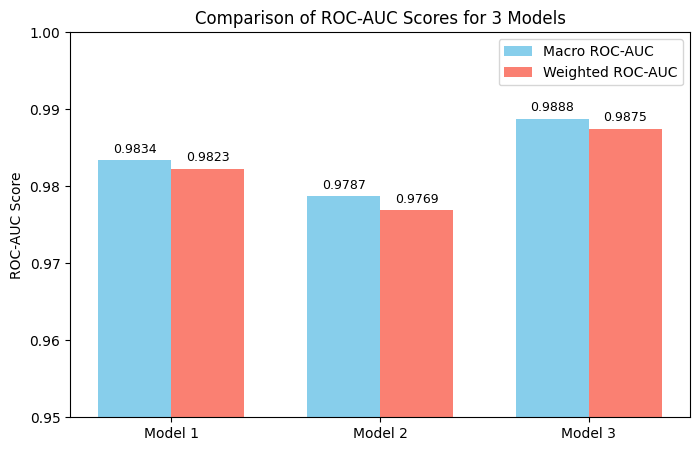

In [187]:
import matplotlib.pyplot as plt
import numpy as np

# Model names
models = ['Model 1', 'Model 2', 'Model 3']

# ROC-AUC scores
macro_scores = [0.9834, 0.9787, 0.9888]
weighted_scores = [0.9823, 0.9769, 0.9875]

# Positions for bars
x = np.arange(len(models))
width = 0.35  # width of the bars

# Create plot
fig, ax = plt.subplots(figsize=(8,5))

# Plot bars
rects1 = ax.bar(x - width/2, macro_scores, width, label='Macro ROC-AUC', color='skyblue')
rects2 = ax.bar(x + width/2, weighted_scores, width, label='Weighted ROC-AUC', color='salmon')

# Add labels and title
ax.set_ylabel('ROC-AUC Score')
ax.set_ylim(0.95, 1.0)  # zoom in for better comparison
ax.set_title('Comparison of ROC-AUC Scores for 3 Models')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

# Add value labels on bars
def add_labels(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0,3),  # offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

add_labels(rects1)
add_labels(rects2)

plt.show()


# Testing the Created Model

In [101]:
def toxicity_level(string):
    new_string = [string]
    new_string = tokenizer.texts_to_sequences(new_string)
    new_string = pad_sequences(new_string, maxlen=maxpadlen, padding='post')

    prediction = loaded_model_final.predict(new_string) #(Change to model_1 or model_2 depending on the preference of model type|| Model 1: LSTM, Model 2:LSTM-CNN)

    print("Toxicity levels for '{}':".format(string))
    print('Toxic:         {:.0%}'.format(prediction[0][0]))
    print('Severe Toxic:  {:.0%}'.format(prediction[0][1]))
    print('Obscene:       {:.0%}'.format(prediction[0][2]))
    print('Threat:        {:.0%}'.format(prediction[0][3]))
    print('Insult:        {:.0%}'.format(prediction[0][4]))
    print('Identity Hate: {:.0%}'.format(prediction[0][5]))
    print()

    return

In [140]:
toxicity_level('go jump off a bridge jerk')

1/1 [==============================] - 1s 1s/step
Toxicity levels for 'go jump off a bridge jerk':
Toxic:         81%
Severe Toxic:  3%
Obscene:       37%
Threat:        1%
Insult:        44%
Identity Hate: 3%



In [142]:
toxicity_level('i will kill you')

1/1 [==============================] - 0s 70ms/step
Toxicity levels for 'i will kill you':
Toxic:         57%
Severe Toxic:  1%
Obscene:       3%
Threat:        26%
Insult:        4%
Identity Hate: 4%



In [144]:
toxicity_level('have a nice day')

1/1 [==============================] - 0s 54ms/step
Toxicity levels for 'have a nice day':
Toxic:         0%
Severe Toxic:  0%
Obscene:       0%
Threat:        0%
Insult:        0%
Identity Hate: 0%



In [199]:
toxicity_level('Hello, How are you?')

1/1 [==============================] - 0s 36ms/step
Toxicity levels for 'Hello, How are you?':
Toxic:         0%
Severe Toxic:  0%
Obscene:       0%
Threat:        0%
Insult:        0%
Identity Hate: 0%



In [197]:
toxicity_level('fuck ofF!!')

1/1 [==============================] - 0s 41ms/step
Toxicity levels for 'fuck ofF!!':
Toxic:         100%
Severe Toxic:  25%
Obscene:       98%
Threat:        1%
Insult:        53%
Identity Hate: 0%



In [201]:
toxicity_level('get the fuck away from me @sshole!!')

1/1 [==============================] - 0s 38ms/step
Toxicity levels for 'get the fuck away from me @sshole!!':
Toxic:         95%
Severe Toxic:  4%
Obscene:       84%
Threat:        0%
Insult:        36%
Identity Hate: 0%



In [203]:
toxicity_level('You are such a disgusting idiot, shut the hell up!')

1/1 [==============================] - 0s 38ms/step
Toxicity levels for 'You are such a disgusting idiot, shut the hell up!':
Toxic:         85%
Severe Toxic:  0%
Obscene:       21%
Threat:        0%
Insult:        47%
Identity Hate: 1%



In [205]:
toxicity_level('You worthless piece of ****, I hope you rot forever')

1/1 [==============================] - 0s 31ms/step
Toxicity levels for 'You worthless piece of ****, I hope you rot forever':
Toxic:         61%
Severe Toxic:  0%
Obscene:       9%
Threat:        0%
Insult:        16%
Identity Hate: 0%



In [156]:
user_input = input("Enter a comment: ")
toxicity_level(user_input)


Enter a comment:  hi


1/1 [==============================] - 0s 147ms/step
Toxicity levels for 'hi':
Toxic:         0%
Severe Toxic:  0%
Obscene:       0%
Threat:        0%
Insult:        0%
Identity Hate: 0%



In [150]:
user_input = input("Enter a comment: ")
toxicity_level(user_input)


Enter a comment:  👿you are such a devil


1/1 [==============================] - 0s 47ms/step
Toxicity levels for '👿you are such a devil':
Toxic:         32%
Severe Toxic:  0%
Obscene:       4%
Threat:        1%
Insult:        7%
Identity Hate: 1%



In [153]:
import re

# Function to normalize repeated characters
def normalize_repeated_chars(text):
    return re.sub(r'(.)\1{2,}', r'\1\1', text)  # reduce 3+ repeats to 2

# Function to take dynamic user input and check toxicity
def check_toxicity():
    user_input = input("Enter a comment: ")
    normalized_input = normalize_repeated_chars(user_input)
    print(f"\nNormalized Comment: {normalized_input}\n")
    toxicity_level(normalized_input)  # calling your existing function

# Run it
check_toxicity()

Enter a comment:  hi



Normalized Comment: hi

1/1 [==============================] - 0s 40ms/step
Toxicity levels for 'hi':
Toxic:         0%
Severe Toxic:  0%
Obscene:       0%
Threat:        0%
Insult:        0%
Identity Hate: 0%



In [145]:
toxicity_level('Get lost no likes your page')

1/1 [==============================] - 1s 896ms/step
Toxicity levels for 'Get lost no likes your page':
Toxic:         0%
Severe Toxic:  0%
Obscene:       0%
Threat:        0%
Insult:        0%
Identity Hate: 0%



In [147]:
toxicity_level('very bad')

1/1 [==============================] - 0s 46ms/step
Toxicity levels for 'very bad':
Toxic:         8%
Severe Toxic:  0%
Obscene:       1%
Threat:        0%
Insult:        1%
Identity Hate: 0%



In [149]:
toxicity_level('This is the worst thing I’ve seen today.')

1/1 [==============================] - 0s 36ms/step
Toxicity levels for 'This is the worst thing I’ve seen today.':
Toxic:         3%
Severe Toxic:  0%
Obscene:       0%
Threat:        0%
Insult:        0%
Identity Hate: 0%



In [151]:
toxicity_level('You look awful in this picture.')

1/1 [==============================] - 0s 37ms/step
Toxicity levels for 'You look awful in this picture.':
Toxic:         19%
Severe Toxic:  0%
Obscene:       2%
Threat:        0%
Insult:        2%
Identity Hate: 0%



In [140]:
from sklearn.metrics import classification_report
import numpy as np

labels = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

def evaluate_model(model, model_name):
    
    print(f"\n{'='*50}")
    print(f"Evaluation for {model_name}")
    print(f"{'='*50}")
    
    # Predict probabilities
    y_pred_prob = model.predict(x_val, batch_size=32)
    
    # Convert to binary (threshold = 0.5)
    y_pred = (y_pred_prob > 0.5).astype(int)
    
    # Classification report
    report = classification_report(y_val, y_pred, target_names=labels)
    print("\nClassification Report:\n")
    print(report)
    
    # Extract macro & weighted metrics
    report_dict = classification_report(y_val, y_pred, target_names=labels, output_dict=True)
    
    results = {
        "Model": model_name,
        "Macro Precision": report_dict['macro avg']['precision'],
        "Macro Recall": report_dict['macro avg']['recall'],
        "Macro F1": report_dict['macro avg']['f1-score'],
        "Weighted Precision": report_dict['weighted avg']['precision'],
        "Weighted Recall": report_dict['weighted avg']['recall'],
        "Weighted F1": report_dict['weighted avg']['f1-score']
    }
    
    return results

In [142]:
results_list = []

# Model 1: LSTM
results_list.append(evaluate_model(loaded_model_1, "LSTM"))

# Model 2: LSTM-CNN
results_list.append(evaluate_model(loaded_model_2, "LSTM-CNN"))

# Model 3: BiLSTM-BiGRU
results_list.append(evaluate_model(loaded_model_final, "BiLSTM-BiGRU"))


Evaluation for LSTM
998/998 [==============================] - 141s 138ms/step

Classification Report:

               precision    recall  f1-score   support

        toxic       0.86      0.70      0.77      3056
 severe_toxic       0.52      0.40      0.45       336
      obscene       0.85      0.76      0.80      1716
       threat       0.00      0.00      0.00        93
       insult       0.72      0.68      0.70      1571
identity_hate       0.65      0.49      0.56       298

    micro avg       0.80      0.68      0.73      7070
    macro avg       0.60      0.50      0.55      7070
 weighted avg       0.79      0.68      0.73      7070
  samples avg       0.06      0.06      0.06      7070


Evaluation for LSTM-CNN
998/998 [==============================] - 168s 166ms/step

Classification Report:

               precision    recall  f1-score   support

        toxic       0.85      0.69      0.76      3056
 severe_toxic       0.00      0.00      0.00       336
      obscen

In [143]:
import pandas as pd

results_df = pd.DataFrame(results_list)

print("\nFinal Comparison Table:\n")
print(results_df)


Final Comparison Table:

          Model  Macro Precision  Macro Recall  Macro F1  Weighted Precision  \
0          LSTM         0.599478      0.504877  0.547116            0.789159   
1      LSTM-CNN         0.414727      0.323666  0.363487            0.749442   
2  BiLSTM-BiGRU         0.719729      0.473543  0.538765            0.829327   

   Weighted Recall  Weighted F1  
0         0.678925     0.729097  
1         0.589392     0.659677  
2         0.687836     0.745181  


998/998 [==============================] - 142s 142ms/step


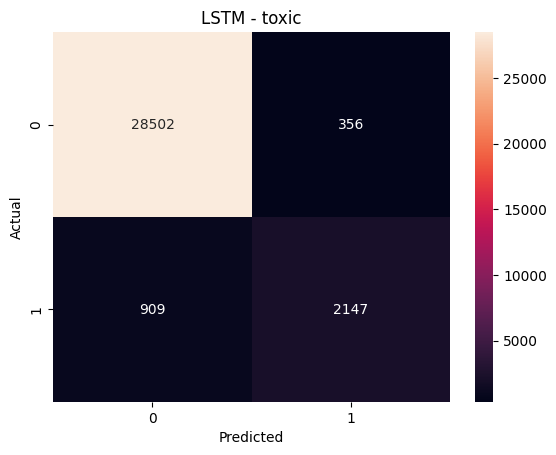

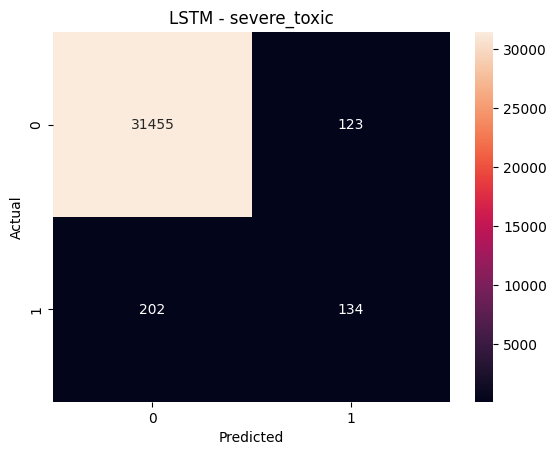

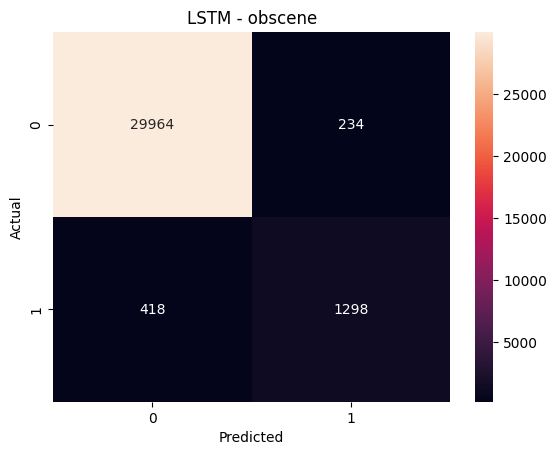

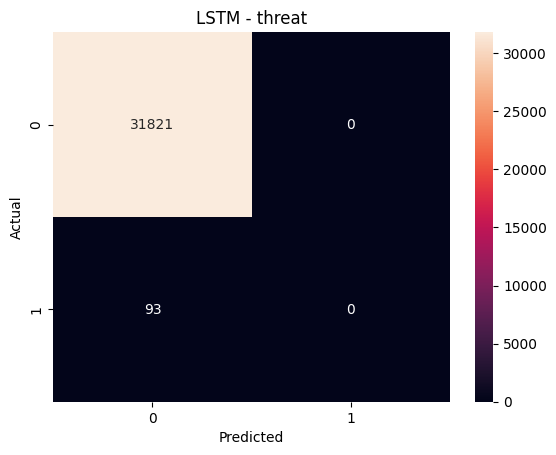

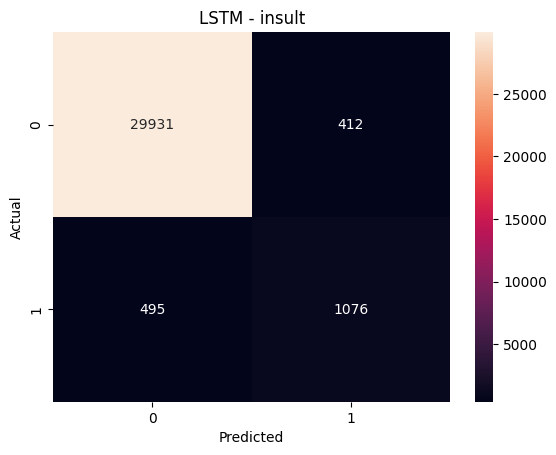

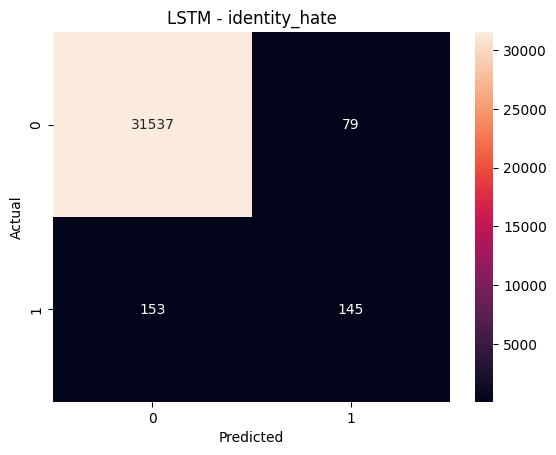

998/998 [==============================] - 186s 187ms/step


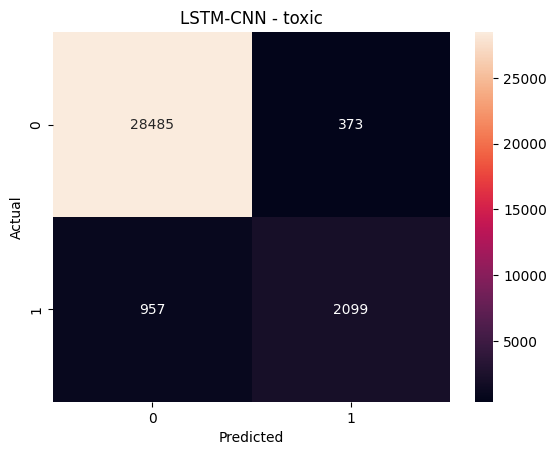

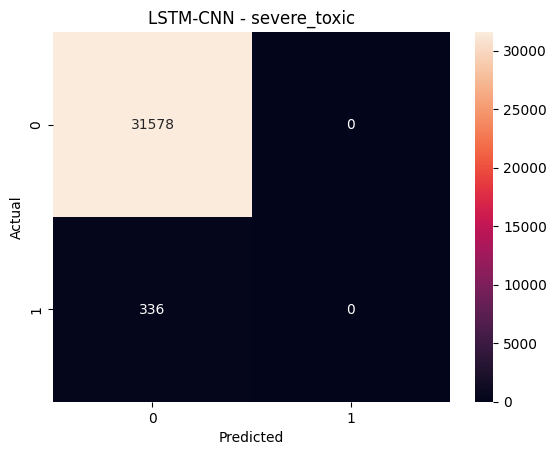

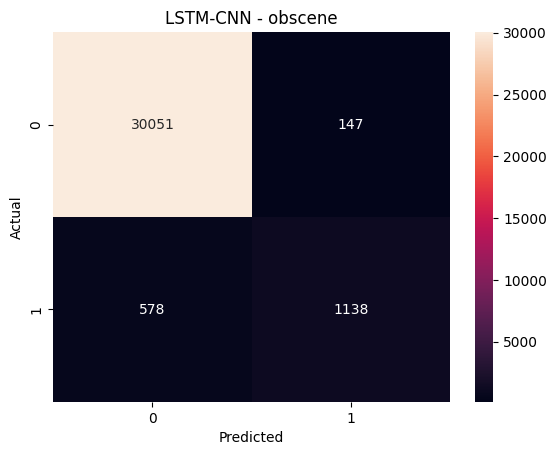

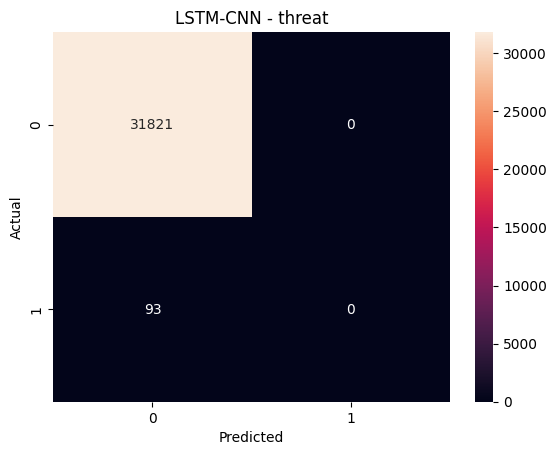

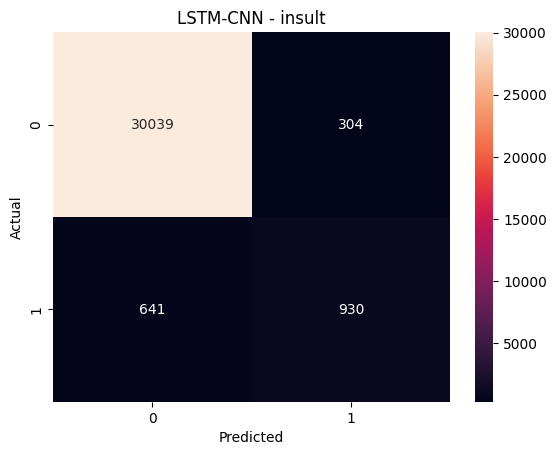

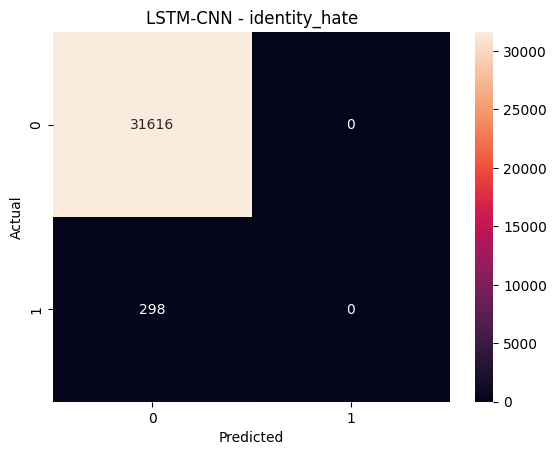

998/998 [==============================] - 368s 368ms/step


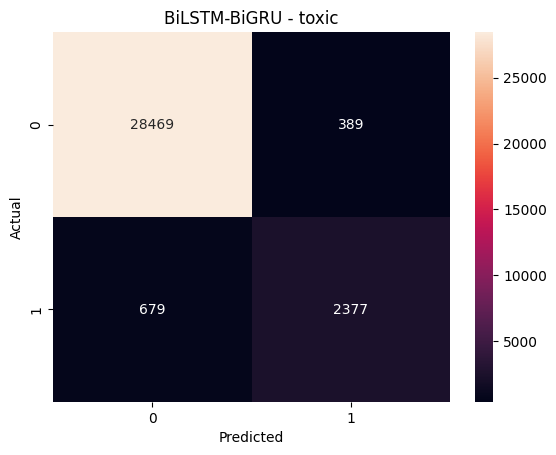

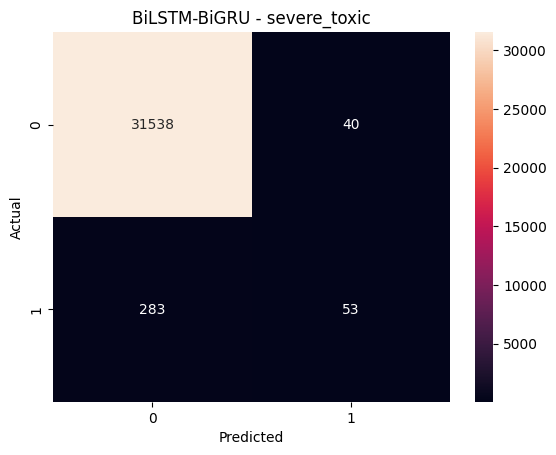

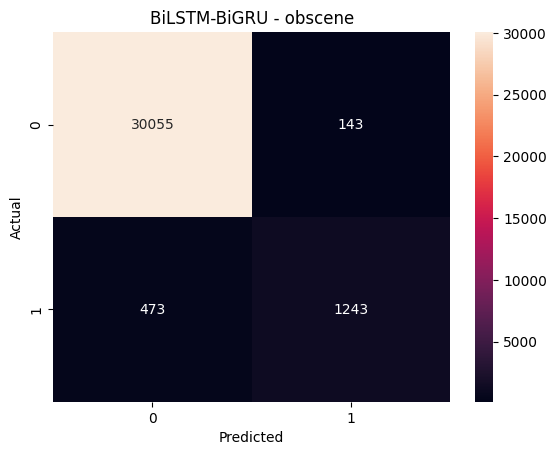

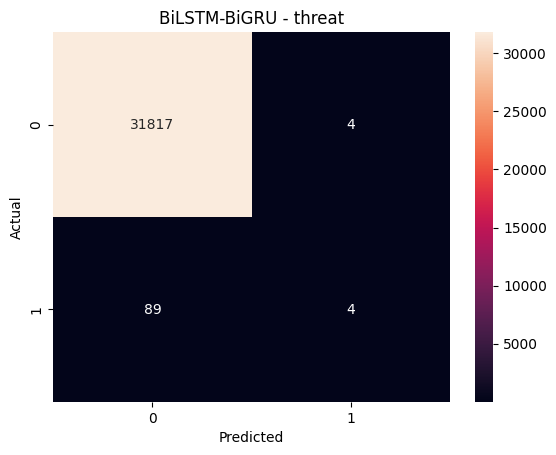

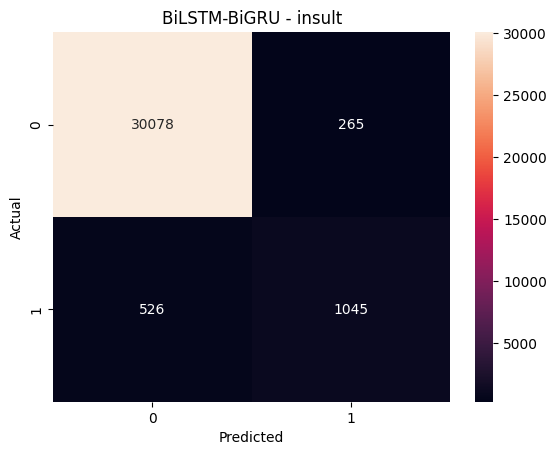

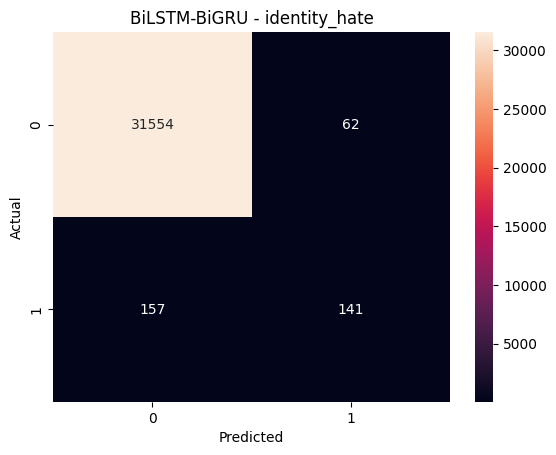

In [144]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import multilabel_confusion_matrix

def plot_confusion_matrix(model, model_name):
    y_pred_prob = model.predict(x_val, batch_size=32)
    y_pred = (y_pred_prob > 0.5).astype(int)
    
    cm = multilabel_confusion_matrix(y_val, y_pred)
    
    for i, label in enumerate(labels):
        plt.figure()
        sns.heatmap(cm[i], annot=True, fmt='d')
        plt.title(f'{model_name} - {label}')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.show()

# Run for all models
plot_confusion_matrix(loaded_model_1, "LSTM")
plot_confusion_matrix(loaded_model_2, "LSTM-CNN")
plot_confusion_matrix(loaded_model_final, "BiLSTM-BiGRU")

In [151]:
# LSTM
y_pred_prob_1 = loaded_model_1.predict(x_val, batch_size=32)

# LSTM-CNN
y_pred_prob_2 = loaded_model_2.predict(x_val, batch_size=32)

# BiLSTM-BiGRU
y_pred_prob_3 = loaded_model_final.predict(x_val, batch_size=32)

998/998 [==============================] - 105s 105ms/step


In [152]:
import numpy as np
from sklearn.metrics import f1_score

def find_best_threshold_per_class(y_true, y_pred_prob):
    
    best_thresholds = []
    
    for i in range(y_true.shape[1]):
        best_t = 0.5
        best_f1 = 0
        
        for t in np.arange(0.1, 0.9, 0.05):
            y_pred = (y_pred_prob[:, i] > t).astype(int)
            f1 = f1_score(y_true[:, i], y_pred)
            
            if f1 > best_f1:
                best_f1 = f1
                best_t = t
        
        best_thresholds.append(best_t)
    
    return best_thresholds

In [153]:
# Find best thresholds
best_t_1 = find_best_threshold_per_class(y_val, y_pred_prob_1)
best_t_2 = find_best_threshold_per_class(y_val, y_pred_prob_2)
best_t_3 = find_best_threshold_per_class(y_val, y_pred_prob_3)

print("LSTM thresholds:", best_t_1)
print("LSTM-CNN thresholds:", best_t_2)
print("BiLSTM-BiGRU thresholds:", best_t_3)

LSTM thresholds: [0.30000000000000004, 0.40000000000000013, 0.3500000000000001, 0.1, 0.3500000000000001, 0.3500000000000001]
LSTM-CNN thresholds: [0.3500000000000001, 0.25000000000000006, 0.25000000000000006, 0.1, 0.3500000000000001, 0.20000000000000004]
BiLSTM-BiGRU thresholds: [0.3500000000000001, 0.25000000000000006, 0.25000000000000006, 0.20000000000000004, 0.3500000000000001, 0.40000000000000013]


In [154]:
def apply_thresholds(y_pred_prob, thresholds):
    
    y_pred = np.zeros_like(y_pred_prob)
    
    for i in range(len(thresholds)):
        y_pred[:, i] = (y_pred_prob[:, i] > thresholds[i]).astype(int)
    
    return y_pred

In [155]:
from sklearn.metrics import classification_report

labels = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

def evaluate_model(y_true, y_pred, model_name):
    
    print(f"\n{'='*50}")
    print(f"{model_name} (Per-Class Threshold)")
    print(f"{'='*50}")
    
    print(classification_report(y_true, y_pred, target_names=labels))


# Apply thresholds
y_pred_1 = apply_thresholds(y_pred_prob_1, best_t_1)
y_pred_2 = apply_thresholds(y_pred_prob_2, best_t_2)
y_pred_3 = apply_thresholds(y_pred_prob_3, best_t_3)

# Evaluate
evaluate_model(y_val, y_pred_1, "LSTM")
evaluate_model(y_val, y_pred_2, "LSTM-CNN")
evaluate_model(y_val, y_pred_3, "BiLSTM-BiGRU")


LSTM (Per-Class Threshold)
               precision    recall  f1-score   support

        toxic       0.79      0.79      0.79      3056
 severe_toxic       0.48      0.59      0.53       336
      obscene       0.79      0.83      0.81      1716
       threat       0.59      0.35      0.44        93
       insult       0.66      0.80      0.72      1571
identity_hate       0.55      0.63      0.59       298

    micro avg       0.73      0.78      0.75      7070
    macro avg       0.64      0.67      0.65      7070
 weighted avg       0.74      0.78      0.76      7070
  samples avg       0.07      0.07      0.07      7070


LSTM-CNN (Per-Class Threshold)
               precision    recall  f1-score   support

        toxic       0.78      0.77      0.77      3056
 severe_toxic       0.45      0.57      0.51       336
      obscene       0.76      0.82      0.79      1716
       threat       0.13      0.15      0.14        93
       insult       0.66      0.77      0.71      1571
i

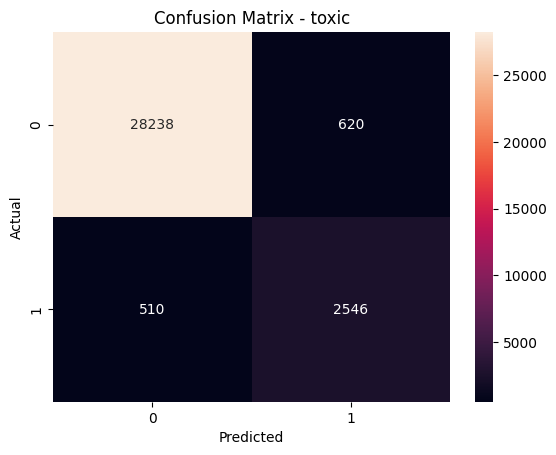

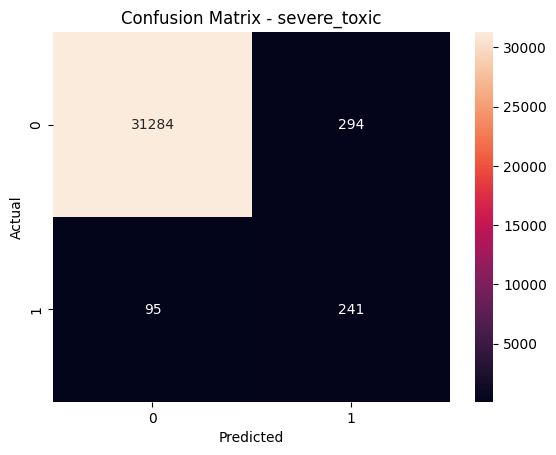

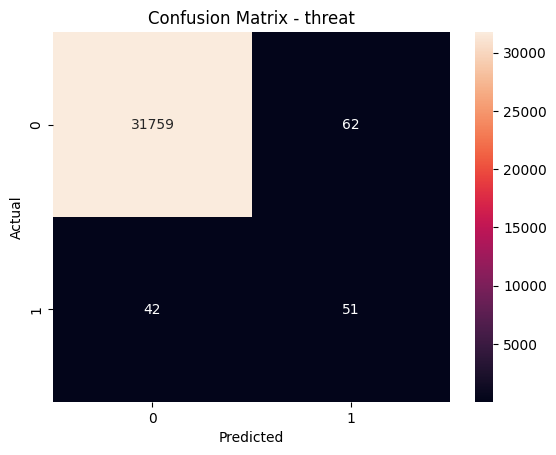

In [161]:
from sklearn.metrics import multilabel_confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

labels = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

cm = multilabel_confusion_matrix(y_val, y_pred_3)

# Show only important classes
important_classes = [0, 1, 3]  # toxic, severe_toxic, threat

for i in important_classes:
    plt.figure()
    sns.heatmap(cm[i], annot=True, fmt='d')
    plt.title(f'Confusion Matrix - {labels[i]}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

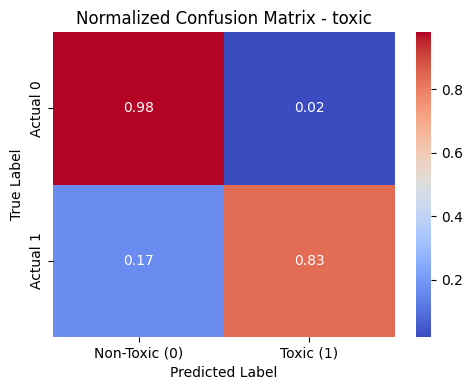

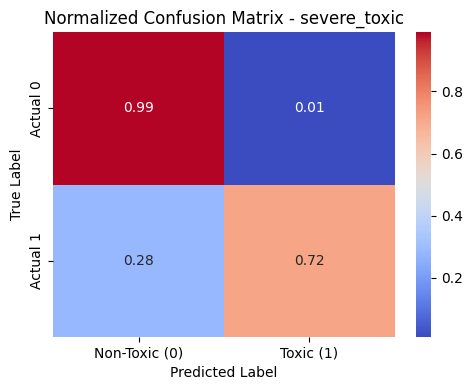

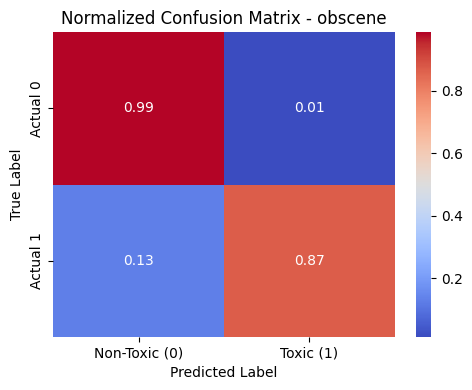

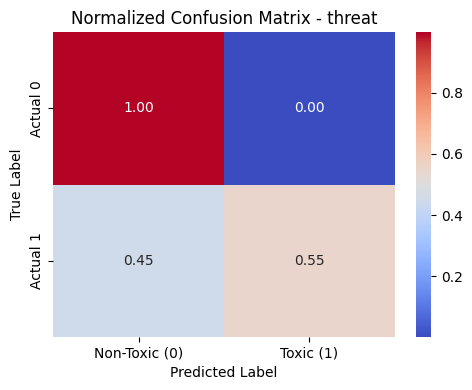

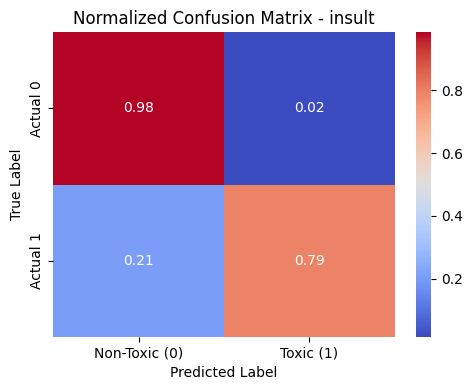

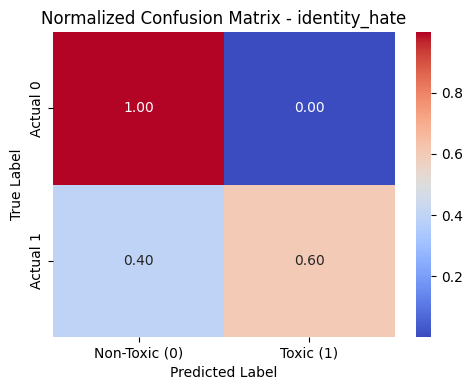

In [167]:
from sklearn.metrics import multilabel_confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Class labels
labels = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

# Get confusion matrices (for best model)
cm = multilabel_confusion_matrix(y_val, y_pred_3)

# Plot all classes
for i in range(len(labels)):
    
    # Normalize (row-wise)
    cm_norm = cm[i].astype('float') / cm[i].sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(5,4))
    sns.heatmap(cm_norm, 
                annot=True, 
                fmt=".2f", 
                cmap="coolwarm",
                xticklabels=["Non-Toxic (0)", "Toxic (1)"],
                yticklabels=["Actual 0", "Actual 1"])
    
    plt.title(f'Normalized Confusion Matrix - {labels[i]}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.savefig(f"cm_{labels[i]}.png", dpi=300)
    plt.show()

In [169]:
from sklearn.metrics import multilabel_confusion_matrix
import numpy as np

labels = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

cm = multilabel_confusion_matrix(y_val, y_pred_3)

for i in range(len(labels)):
    print("\n==============================")
    print(f"Class: {labels[i]}")
    print("==============================")

    cm_norm = cm[i].astype('float') / cm[i].sum(axis=1)[:, np.newaxis]

    print("               Predicted 0    Predicted 1")
    print(f"Actual 0        {cm_norm[0][0]:.2f}           {cm_norm[0][1]:.2f}")
    print(f"Actual 1        {cm_norm[1][0]:.2f}           {cm_norm[1][1]:.2f}")


Class: toxic
               Predicted 0    Predicted 1
Actual 0        0.98           0.02
Actual 1        0.17           0.83

Class: severe_toxic
               Predicted 0    Predicted 1
Actual 0        0.99           0.01
Actual 1        0.28           0.72

Class: obscene
               Predicted 0    Predicted 1
Actual 0        0.99           0.01
Actual 1        0.13           0.87

Class: threat
               Predicted 0    Predicted 1
Actual 0        1.00           0.00
Actual 1        0.45           0.55

Class: insult
               Predicted 0    Predicted 1
Actual 0        0.98           0.02
Actual 1        0.21           0.79

Class: identity_hate
               Predicted 0    Predicted 1
Actual 0        1.00           0.00
Actual 1        0.40           0.60


In [171]:
import pandas as pd

labels = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

# Full dataset distribution
print("=== FULL DATASET DISTRIBUTION ===")
print(train[labels].sum())

# Training set distribution
print("\n=== TRAINING SET DISTRIBUTION ===")
print(pd.DataFrame(y_train, columns=labels).sum())

# Validation set distribution
print("\n=== VALIDATION SET DISTRIBUTION ===")
print(pd.DataFrame(y_val, columns=labels).sum())

=== FULL DATASET DISTRIBUTION ===
toxic            15294
severe_toxic      1595
obscene           8449
threat             478
insult            7877
identity_hate     1405
dtype: int64

=== TRAINING SET DISTRIBUTION ===
toxic            12238
severe_toxic      1259
obscene           6733
threat             385
insult            6306
identity_hate     1107
dtype: int64

=== VALIDATION SET DISTRIBUTION ===
toxic            3056
severe_toxic      336
obscene          1716
threat             93
insult           1571
identity_hate     298
dtype: int64


===== TOXIC =====


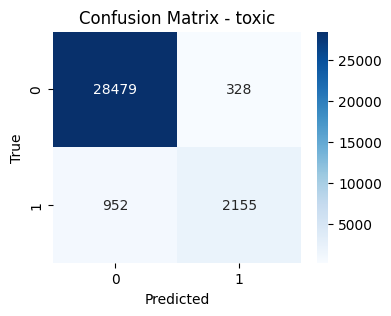

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     28807
           1       0.87      0.69      0.77      3107

    accuracy                           0.96     31914
   macro avg       0.92      0.84      0.87     31914
weighted avg       0.96      0.96      0.96     31914

===== SEVERE_TOXIC =====


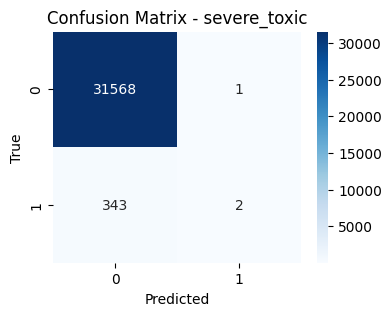

              precision    recall  f1-score   support

           0       0.99      1.00      0.99     31569
           1       0.67      0.01      0.01       345

    accuracy                           0.99     31914
   macro avg       0.83      0.50      0.50     31914
weighted avg       0.99      0.99      0.98     31914

===== OBSCENE =====


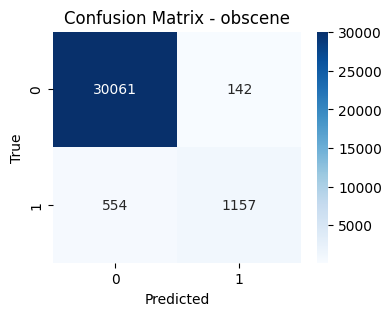

              precision    recall  f1-score   support

           0       0.98      1.00      0.99     30203
           1       0.89      0.68      0.77      1711

    accuracy                           0.98     31914
   macro avg       0.94      0.84      0.88     31914
weighted avg       0.98      0.98      0.98     31914

===== THREAT =====


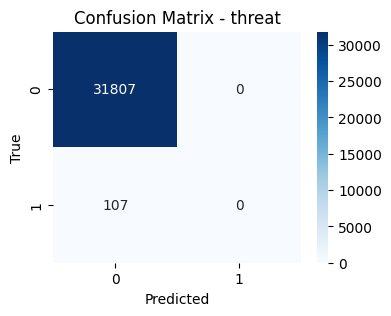

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     31807
           1       0.00      0.00      0.00       107

    accuracy                           1.00     31914
   macro avg       0.50      0.50      0.50     31914
weighted avg       0.99      1.00      0.99     31914

===== INSULT =====


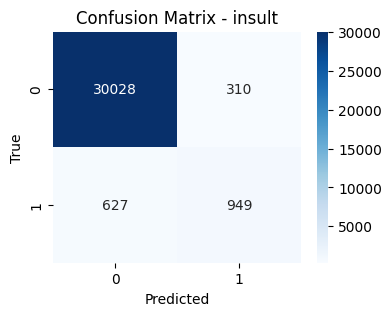

              precision    recall  f1-score   support

           0       0.98      0.99      0.98     30338
           1       0.75      0.60      0.67      1576

    accuracy                           0.97     31914
   macro avg       0.87      0.80      0.83     31914
weighted avg       0.97      0.97      0.97     31914

===== IDENTITY_HATE =====


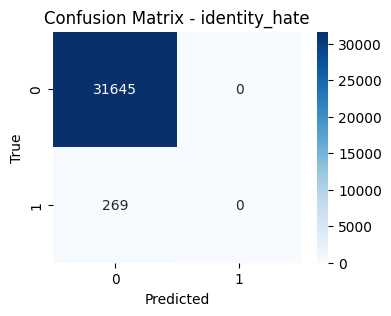

              precision    recall  f1-score   support

           0       0.99      1.00      1.00     31645
           1       0.00      0.00      0.00       269

    accuracy                           0.99     31914
   macro avg       0.50      0.50      0.50     31914
weighted avg       0.98      0.99      0.99     31914



In [225]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Example: your labels list
labels = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

# Convert predictions to binary using threshold 0.5
y_pred_binary = (val_preds > 0.5).astype(int)

# Loop through each label
for i, label in enumerate(labels):
    print(f"===== {label.upper()} =====")

    # Confusion matrix
    cm = confusion_matrix(y_val[:, i], y_pred_binary[:, i])
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {label}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    # Classification report for each label
    print(classification_report(y_val[:, i], y_pred_binary[:, i]))


In [227]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Example: your labels
labels = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

# Convert predictions to binary using threshold 0.5
y_pred_binary = (val_preds > 0.5).astype(int)

# Folder to save confusion matrices
save_dir = "confusion_matrices"
os.makedirs(save_dir, exist_ok=True)

# Loop through each label
for i, label in enumerate(labels):
    print(f"===== {label.upper()} =====")
    
    # Confusion Matrix
    cm = confusion_matrix(y_val[:, i], y_pred_binary[:, i])
    
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix - {label}')
    plt.xlabel('Predicted')
    plt.ylabel('True')

    # Save image
    save_path = os.path.join(save_dir, f"{label}_confusion_matrix.png")
    plt.savefig(save_path, bbox_inches='tight')
    plt.close()

    print(f"Saved: {save_path}\n")

    # Classification Report
    print(classification_report(y_val[:, i], y_pred_binary[:, i]))

# Optional: Print full report across all labels
print("\n====== Overall Multi-label Classification Report ======")
print(classification_report(y_val, y_pred_binary, target_names=labels))


===== TOXIC =====
Saved: confusion_matrices\toxic_confusion_matrix.png

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     28807
           1       0.87      0.69      0.77      3107

    accuracy                           0.96     31914
   macro avg       0.92      0.84      0.87     31914
weighted avg       0.96      0.96      0.96     31914

===== SEVERE_TOXIC =====
Saved: confusion_matrices\severe_toxic_confusion_matrix.png

              precision    recall  f1-score   support

           0       0.99      1.00      0.99     31569
           1       0.67      0.01      0.01       345

    accuracy                           0.99     31914
   macro avg       0.83      0.50      0.50     31914
weighted avg       0.99      0.99      0.98     31914

===== OBSCENE =====
Saved: confusion_matrices\obscene_confusion_matrix.png

              precision    recall  f1-score   support

           0       0.98      1.00      0.99     30203
   

In [229]:
from sklearn.metrics import f1_score
import numpy as np

best_thresholds = []

for i, label in enumerate(labels):
    best_f1 = 0
    best_t = 0.5
    for t in np.arange(0.1, 0.9, 0.01):
        preds_t = (val_preds[:, i] > t).astype(int)
        f1 = f1_score(y_val[:, i], preds_t)
        if f1 > best_f1:
            best_f1 = f1
            best_t = t
    best_thresholds.append(best_t)
    print(f"{label}: Best threshold = {best_t:.2f}, Best F1 = {best_f1:.3f}")


toxic: Best threshold = 0.39, Best F1 = 0.783
severe_toxic: Best threshold = 0.26, Best F1 = 0.510
obscene: Best threshold = 0.32, Best F1 = 0.796
threat: Best threshold = 0.10, Best F1 = 0.123
insult: Best threshold = 0.36, Best F1 = 0.717
identity_hate: Best threshold = 0.21, Best F1 = 0.490


In [231]:
y_pred_optimized = np.zeros_like(val_preds)
for i in range(len(labels)):
    y_pred_optimized[:, i] = (val_preds[:, i] > best_thresholds[i]).astype(int)


In [233]:
from sklearn.metrics import classification_report

print("\n====== Final Optimized Classification Report ======")
print(classification_report(y_val, y_pred_optimized, target_names=labels))



====== Final Optimized Classification Report ======
               precision    recall  f1-score   support

        toxic       0.82      0.75      0.78      3107
 severe_toxic       0.48      0.54      0.51       345
      obscene       0.81      0.79      0.80      1711
       threat       0.12      0.12      0.12       107
       insult       0.67      0.77      0.72      1576
identity_hate       0.42      0.59      0.49       269

    micro avg       0.73      0.74      0.73      7115
    macro avg       0.55      0.59      0.57      7115
 weighted avg       0.74      0.74      0.74      7115
  samples avg       0.06      0.07      0.06      7115



In [235]:
import os, seaborn as sns, matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

save_dir = "confusion_matrices_optimized"
os.makedirs(save_dir, exist_ok=True)

for i, label in enumerate(labels):
    cm = confusion_matrix(y_val[:, i], y_pred_optimized[:, i])
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Optimized Confusion Matrix - {label}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.savefig(os.path.join(save_dir, f"{label}_cm_optimized.png"), bbox_inches='tight')
    plt.close()
    print(f"Saved: {label}_cm_optimized.png")


Saved: toxic_cm_optimized.png
Saved: severe_toxic_cm_optimized.png
Saved: obscene_cm_optimized.png
Saved: threat_cm_optimized.png
Saved: insult_cm_optimized.png
Saved: identity_hate_cm_optimized.png
